In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import math
import re
import base64

In [2]:
import Xm

In [3]:
#xm=Xm.Xm(XmlFile='../testdata/FW.XML') # "C:\3S\Modelle\MVV_FW.XML"
xm=Xm.Xm(XmlFile=r'C:\3S\Modelle\MVV_FW.XML')

# LAYR

In [ ]:
xm.vLAYR_DATA.sort_values(by=['LFDNR']).head(10)

In [ ]:
xm.vLAYR_OBJS.sort_values(by=['LFDNR','OBJID']).head(10)

In [ ]:
xm.vLAYR_OBJS.info(memory_usage='deep')

In [ ]:
xm.vLAYR.info(memory_usage='deep')

In [ ]:
xm.vLAYR.info()

In [ ]:
xm.vLAYR.sort_values(by=['NAME','LFDNR','OBJTYPE','OBJID']).head()

In [ ]:
xm.vLAYR[xm.vLAYR['NAME']=='NDD Trassen'].head()

In [ ]:
print(len(xm.vLAYR[xm.vLAYR['NAME']=='NDD Trassen']))

# Model

In [ ]:
df=xm.dataFrames['MODELL']
df.head()

In [ ]:
x=df['MEMOTEXT'].str[:]

In [ ]:
print(x)

In [ ]:
print(x.iloc[0])

In [ ]:
bStr=base64.b64decode(x.iloc[0])
print(bStr)

In [ ]:
bStr.decode('utf-8')

=== LFKT ===

In [ ]:
xm.vLFKT.head()

=== FWVB ===

In [ ]:
xm.vFWVB.head()

In [ ]:
xm.vFWVB.columns

In [ ]:
#ROHR

In [ ]:
xm.vROHR.columns

In [ ]:
xm.vKNOT.columns

# lagerichtige Darstellung


In [131]:
# alle FWVB eines Blockes - i.d.R. des Netzes
cID=1001
pFWVB=xm.vFWVB[(xm.vFWVB['CONT_ID'].astype(int)==cID) & (xm.vFWVB['W0']>0)].sort_values(by=['W0'],ascending=True)

In [132]:
pFWVB.head()

,BESCHREIBUNG,IDREFERENZ,W0,LFK,TVL0,TRS0,LFKT,W,W_min,W_max,...,ZKOR_i,NAME_k,KVR_k,TM_k,XKOR_k,YKOR_k,ZKOR_k,CONT,CONT_ID,CONT_LFDNR
10285,0027000100080b5d,0027000100080b5d,0.009,1,130,60,LfTh,0.009,0.009,0.009,...,94.49,K5195,2,50,3461493.129,5481051.889,94.49,M-1-0-1,1001,1
3270,002700010007ad01,002700010007ad01,0.013,1,130,60,LfTh,0.013,0.013,0.013,...,94.49,K55059,2,50,3464196.854,5480164.006,94.49,M-1-0-1,1001,1
9748,002700010007f343,002700010007f343,0.055,1,130,60,LfTh,0.055,0.055,0.055,...,93.13,K12261,2,50,3461849.629,5483522.11,93.13,M-1-0-1,1001,1
10848,002700010007af1c,002700010007af1c,0.063,1,130,60,LfTh,0.063,0.063,0.063,...,97.38,K54312,2,60,3463824.164,5487637.196,97.38,M-1-0-1,1001,1
469,002700010007a8c7,002700010007a8c7,0.063,1,130,60,LfTh,0.063,0.063,0.063,...,93.76,K67365,2,50,3465129.666,5478132.363,93.76,M-1-0-1,1001,1


In [133]:
xFWVB=[x for x in pFWVB['XKOR_i'].astype(float)]#-pFWVB['XKOR_i'].astype(float).min()]

In [134]:
yFWVB=[x for x in pFWVB['YKOR_i'].astype(float)]#-pFWVB['YKOR_i'].astype(float).min()]

In [135]:
norm = colors.Normalize(0,pFWVB['W0'].max())
W0colors=[]
for W0 in pFWVB['W0']:
    color = plt.cm.cool(norm(W0))
    W0colors.append(color)

In [136]:
pROHR=xm.vROHR[(xm.vROHR['CONT_ID'].astype(int)==cID) & (xm.vROHR['KVR'].astype(int)==1)]

In [137]:
pROHR=pd.merge(pROHR,xm.vLAYR,left_on='pk',right_on='OBJID')

In [138]:
pROHR=pROHR[pROHR['NAME'] == 'NDD Trassen']

In [139]:
print(len(pROHR))

1867


In [140]:
pROHR=pROHR.groupby('OBJID').filter(lambda x: len(x) == 1)

In [141]:
xis=[x for x in pROHR['XKOR_i'].astype(float)]#-pFWVB['XKOR_i'].astype(float).min()]
xks=[x for x in pROHR['XKOR_k'].astype(float)]#-pFWVB['XKOR_k'].astype(float).min()]
yis=[x for x in pROHR['YKOR_i'].astype(float)]#-pFWVB['YKOR_i'].astype(float).min()]
yks=[x for x in pROHR['YKOR_k'].astype(float)]#-pFWVB['YKOR_k'].astype(float).min()]

In [142]:
xZero=min(pFWVB['XKOR_i'].astype(float).min(),pROHR['XKOR_i'].astype(float).min())
xZero=min(xZero,pROHR['XKOR_k'].astype(float).min())
print(xZero)

3457526.19653


In [143]:
yZero=min(pFWVB['YKOR_i'].astype(float).min(),pROHR['YKOR_i'].astype(float).min())
yZero=min(yZero,pROHR['YKOR_k'].astype(float).min())
print(yZero)

5464310.11873


In [144]:
xFWVB=[x-xZero for x in xFWVB]

In [145]:
yFWVB=[x-yZero for x in yFWVB]

In [146]:
xis=[x-xZero for x in xis]
xks=[x-xZero for x in xks]
yis=[x-yZero for x in yis]
yks=[x-yZero for x in yks]

In [147]:
xses=[[xi,xk] for xi,xk in zip(xis,xks)]
yses=[[yi,yk] for yi,yk in zip(yis,yks)]
print(len(xses))

1867


In [148]:
xRMin=min(min(xis),min(xks))
yRMin=min(min(yis),min(yks))
print(xRMin)
print(yRMin)

0.0
0.0


In [149]:
print(min(xFWVB))
print(min(yFWVB))

0.0
0.0


In [150]:
xRMax=max(max(xis),max(xks))
yRMax=max(max(yis),max(yks))
print(xRMax)
print(yRMax)

11318.56447
27835.46027


In [151]:
#### Plot

In [152]:
#%matplotlib inline

In [153]:
dxInch=10

In [154]:
dy=max(max(yFWVB),yRMax)
dx=max(max(xFWVB),xRMax)

In [155]:
dydx=dy/dx

In [156]:
plt.close('all')
fig=plt.figure(
    frameon=True
    ,linewidth=1.
    ,edgecolor='b'
#    figsize=(dxInch,dxInch*dydx)
)
fig.set_figwidth(dxInch)
#colorbar
fraction=0.05
pad=0.05
factor=1-(fraction+pad)
fig.set_figheight(dxInch*dydx*factor)
ax=plt.subplot()

In [157]:
#dir(fig)

In [158]:
maxSize=20

In [159]:
pCol=ax.scatter(xFWVB,yFWVB,s=maxSize*pFWVB['W0']/pFWVB['W0'].max()
                #,c=W0colors
                ,cmap=plt.cm.cool
                ,c=pFWVB['W0']
                ,alpha=0.9
                ,edgecolors='face'
               ,vmin=0
                ,vmax=1448.3
                #pFWVB['W0'].max() # Note if you pass a norm instance, your settings for vmin and vmax will be ignored.
                ,clip_on=False
               )
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlim(right=dx)
ax.set_ylim(top=dy)
#ax.autoscale(enable=True)
#ax.autoscale_view(tight=True)

(0.0, 27835.46026999969)

In [160]:
normR = colors.Normalize(pROHR['DI'].astype(float).min(),pROHR['DI'].astype(float).max())
DIs=pROHR['DI'].astype(float)
DIMax=pROHR['DI'].astype(float).max()

In [161]:
for xs,ys,DI in zip(xses,yses,DIs):
    colorR = plt.cm.binary(normR(DI))
    ax.plot(xs,ys,color=colorR,linewidth=1.0*DI/DIMax, ls='-',marker='')

In [162]:
from matplotlib.colorbar import make_axes

In [163]:
cax,kw=make_axes(ax
                ,fraction=fraction
                 ,anchor=(0.,0.)
                 ,pad=pad
                 ,aspect=10.
                 ,shrink=0.25
                )
print(kw)

{'ticklocation': 'right', 'orientation': 'vertical'}


In [164]:
#kw['drawedges']=True
#kw['boundaries']=True

In [165]:
cB=fig.colorbar(pCol
                ,cax=cax
                ,**kw
               # ,ax=ax
              #  ,fraction=0.025
               )

In [166]:
cB.set_ticks([0.,1400.])
cB.set_ticklabels(['0','^1400'])
cB.set_label('kW')

In [167]:
#c=ax.get_clip_box()
#print(c)
ax.get_data_ratio()
ax.get_frame_on()
#ax.get_tightbbox(fig)
ax.get_window_extent()

TransformedBbox(Bbox([[0.125, 0.125], [0.8224999999999999, 0.9]]), BboxTransformTo(TransformedBbox(Bbox([[0.0, 0.0], [10.0, 14.663157427806539]]), Affine2D(array([[ 72.,   0.,   0.],
       [  0.,  72.,   0.],
       [  0.,   0.,   1.]])))))

In [168]:
cax.get_window_extent()

TransformedBbox(Bbox([[0.86125, 0.125], [0.9, 0.31875]]), BboxTransformTo(TransformedBbox(Bbox([[0.0, 0.0], [10.0, 14.663157427806539]]), Affine2D(array([[ 72.,   0.,   0.],
       [  0.,  72.,   0.],
       [  0.,   0.,   1.]])))))

In [169]:
#fig.set_figheight(fig.get_figheight()*0.9)

In [170]:
plt.savefig('x.pdf'
,dpi=300 #'figure'
)

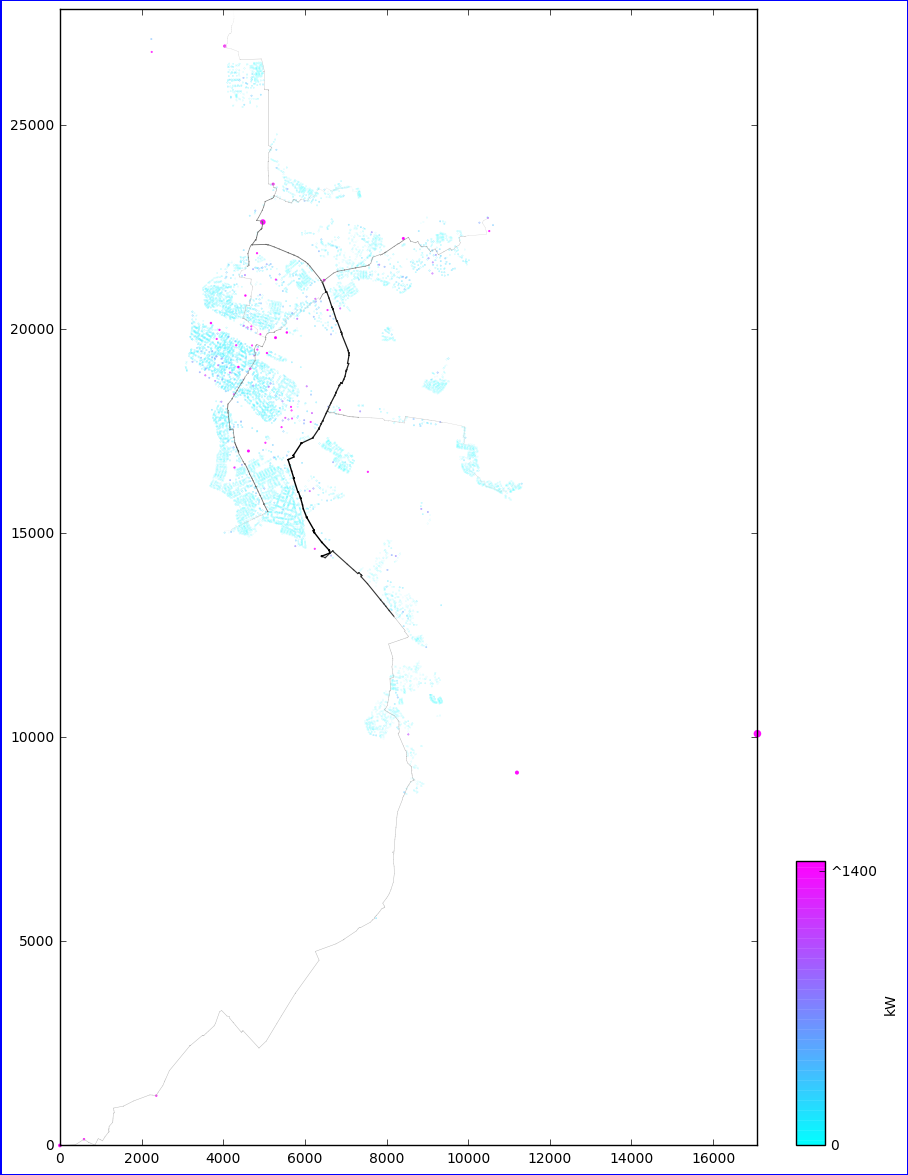

In [171]:
plt.show()

In [ ]:
plt.close('all')
fig=plt.figure()
ax=plt.subplot()

In [ ]:
xm.vFWVB_Plt_Hist()

In [ ]:
txt=ax.set_xlabel('vFWVB_Plt_Hist')

In [ ]:
plt.show()

In [ ]:
xm.vFWVB.XKOR_i=pd.to_numeric(xm.vFWVB.XKOR_i) 

In [ ]:
xm.vFWVB.XKOR_i= xm.vFWVB.XKOR_i.min()

In [ ]:
xm.vFWVB.head()

# xxxx

In [ ]:
xm.vVKNO.head(5)


In [ ]:
xm.vKNOT.head(5)

In [ ]:
xm.vKNOT[['NAME']].size

In [ ]:
xm.vKNOT[(xm.vKNOT['KTYP'].isin(['QKON']) & xm.vKNOT['QM_EIN'].astype(float)!=0) | xm.vKNOT['KTYP'].isin(['QVAR'])][[
                    'NAME'              
                   ,'CONT'
                   ,'CONT_VKNO' # vVKNO
                   ,'KTYP'
                   ,'LFAKT','QM_EIN','QVAR','QM','QM_min','QM_max'     
                   ,'KVR' 
                   ,'TE','TM'                   
    ]].sort_values(by=['CONT_VKNO','NAME'])

In [ ]:
xm.pRSLW.head()

In [ ]:
xm.dataFrames['NRCV'].columns

In [ ]:
vDPGR=pd.merge(xm.dataFrames['DPGR'],xm.dataFrames['DPGR_BZ'],left_on='pk',right_on='fk')

In [ ]:
vDPGR.columns

In [ ]:
vDPGR=vDPGR[[
        # DPGR
        'NAME'
        # DPGR IDs
       ,'pk_x', 'tk'
        # DPGR_BZ        
    ]]

In [ ]:
vDPGR.rename(columns={'pk_x':'pk'},inplace=True)

In [ ]:
vDPGR=pd.merge(vDPGR,xm.dataFrames['DPGR_ROWS'],left_on='pk',right_on='fk')

In [ ]:
vDPGR.columns

In [ ]:
vDPGR=vDPGR[[
        # DPGR
        'NAME'
        # DPGR_BZ   
        # DPGR_ROWS
       ,'OBJTYPE','NAME1','NAME2','NAME3','ATTRTYPE'
       ,'ADDEND','FACTOR','DEVIATION'
       ,'FLAGS','CLIENT_FLAGS'
       ,'DESCRIPTION','TITLE','UNIT' 
       ,'DATALENGTH', 'DATATYPE'
       ,'LOWER_LIMIT','UPPER_LIMIT'
       ,'OL3COMMAND','EPKZ'
        # DPGR IDs
       ,'pk_x', 'tk_x'  
       ,'fkOBJTYPE'
       # DPGR_ROWS IDs 
       ,'pk_y','tk_y'
    ]]

In [ ]:
cDct=dict(zip(vDPGR,vDPGR))

In [ ]:
vDPGR.rename(columns={'pk_x':'pk','tk':'tk','pk_y':'pkROWS','tk_y':'tkROWS'},inplace=True)

In [ ]:
xm.dataFrames['DPGR_ROWS'].columns

In [ ]:
vDPGR.head()

In [ ]:
pd.merge(vDPGR,xm.dataFrames[vDPGR.apply(lambda row: row.OBJTYPE, axis=1)],left_on='fkOBJTYPE',right_on='pk')

In [ ]:
xm.vKNOT.columns

In [ ]:
sorted(xm.dataFrames.keys())